# ETL - Preprocesamiento de Imágenes de Basura

Este notebook:
* Carga y valida imágenes (evita errores por imágenes corruptas)
* Normalización (escalado de pixeles a rango [0,1])
* Muestra imagenes después de normalización para verificar que el proceso se realizó correctamente
* Guarda los datasets preprocesados para usar en el modelo 
* Guarda metadatos de las imagenes para pasar al modelo

Carlos Iván Fonseca Mondragón | A01771689

In [23]:
# Importación de librerías
import os
import PIL
import joblib
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from keras.utils import image_dataset_from_directory
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img

In [24]:
# Verificar si TensorFlow detecta la GPU
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    print("GPU detectada:", physical_devices)
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
else:
    print("No se detectó GPU. Asegúrate de que TensorFlow esté configurado correctamente.")

GPU detectada: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Configuración de parámetros

In [25]:
# Configuración de parámetros
randomizer = 42 # Semilla para reproducibilidad
IMAGE_SIZE = (224, 224) # Tamaño para las imágenes
BATCH_SIZE = 32

BASE_PATHS = {
    "train_path" : "train/",
    "test_path" : "test/",
}

# Usar AUTOTUNE para mejorar rendimiento de I/O
AUTOTUNE = tf.data.AUTOTUNE

# Directorio para guardar datasets preprocesados
os.makedirs("processed_datasets", exist_ok=True)

## Cargar datasets crudos

In [26]:
# Crear split train/validation con el parámetro validation_split 
train_dataset = image_dataset_from_directory(
    BASE_PATHS["train_path"],
    labels='inferred',
    label_mode='categorical',
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    shuffle=True,
    seed=randomizer,
    validation_split=0.1,
    subset="training"
)
validation_dataset = image_dataset_from_directory(
    BASE_PATHS["train_path"],
    labels='inferred',
    label_mode='categorical',
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    shuffle=True,
    seed=randomizer,
    validation_split=0.1,
    subset="validation"
)

# Dataset de prueba (se mantiene separado en test_path)
test_dataset = image_dataset_from_directory(
    BASE_PATHS["test_path"],
    labels='inferred',
    label_mode='categorical',
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    shuffle=True,
    seed=randomizer
)

# Obtener class_names
train_class_names = train_dataset.class_names

Found 3806 files belonging to 9 classes.
Using 3426 files for training.
Found 3806 files belonging to 9 classes.
Using 380 files for validation.
Found 957 files belonging to 9 classes.


## Validar imágenes

In [27]:
errors = 0 

for key, path in BASE_PATHS.items():
    for root, dirs, files in os.walk(path):
        for filename in files:
            if filename.lower().endswith((".jpg", ".png")):
                try:
                    img = PIL.Image.open(os.path.join(root, filename))
                    img.verify()
                except (IOError, SyntaxError) as e:
                    print(f"Imagen corrupta encontrada: {filename} - {e}") 
                    os.remove(os.path.join(root, filename))
                    print(f"Imagen corrupta eliminada: {filename}")
                    errors += 1

if errors != 0:
    print("Se detectaron y eliminaron " + str(errors) + " imágenes corruptas, vuelve a ejecutar el notebook para evitar problemas en la creación del dataset")

print(f"Total de imágenes corruptas encontradas: {errors}")


Total de imágenes corruptas encontradas: 0


## Normalización

In [28]:
# Normalización de imágenes RGB 
normalization_layer = tf.keras.layers.Rescaling(1./255)

def normalize_images(x, y):
    return normalization_layer(x), y

In [29]:
# Pipeline de datos de train, validation y test(incluye normalización y un prefetch para mejorar rendimiento)
normalized_train_dataset = (train_dataset.map(normalize_images, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE))
normalized_validation_dataset = validation_dataset.map(normalize_images, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
normalized_test_dataset = test_dataset.map(normalize_images, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)


## Visualización de imágenes después de preprocesamiento

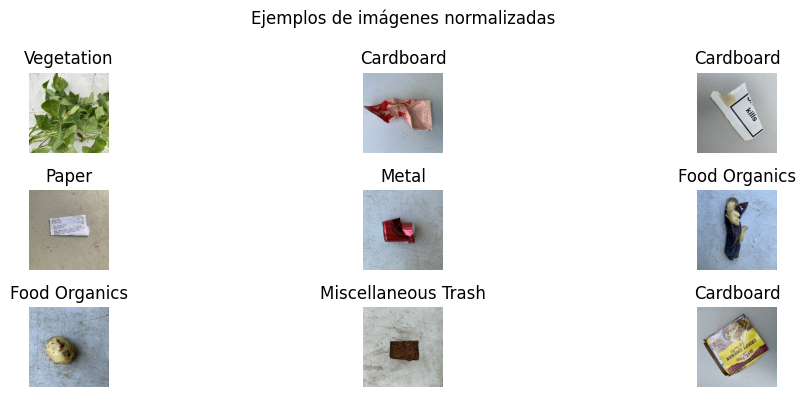

In [30]:
# Visualización de imágenes después de normalización
sample_batch = next(iter(normalized_train_dataset))
images, labels = sample_batch

plt.figure(figsize=(12, 4))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy())
    plt.title(train_class_names[tf.argmax(labels[i])])
    plt.axis("off")
plt.suptitle("Ejemplos de imágenes normalizadas")
plt.tight_layout()
plt.show()

## Calcular pesos de clase (deprecado el modelo actual)

In [31]:
# Diccionario de pesos de clase para manejar el desbalanceo
labels_list = []
for _, batch_labels in train_dataset.unbatch():
    labels_list.append(tf.argmax(batch_labels).numpy())

labels_array = np.array(labels_list)

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(labels_array), y=labels_array)

weight_dict = dict(enumerate(class_weights))
print("Pesos de clase calculados:")
for class_id, weight in weight_dict.items():
    print(f"{train_class_names[class_id]}: {weight:.4f}")

Pesos de clase calculados:
Cardboard: 1.0876
Food Organics: 1.2904
Glass: 1.2440
Metal: 0.6737
Miscellaneous Trash: 1.0845
Paper: 1.0545
Plastic: 0.5759
Textile Trash: 1.6551
Vegetation: 1.2400


2026-05-31 19:55:36.315695: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Guardar datasets preprocesados

In [32]:
# Se guardan utilzando la función save de TensorFlow
# Solo se guarda normalización, sin augmentation, pues esta se aplica en el notebook del modelo

normalized_train_dataset.save("processed_datasets/train")
normalized_validation_dataset.save("processed_datasets/validation")
normalized_test_dataset.save("processed_datasets/test")

print("Datasets guardados en processed_datasets/")

Datasets guardados en processed_datasets/


In [33]:
# Guardar metadatos con joblib, para que el notebook de entrenamiento del modelo pueda usarlos facilmente
metadata = {
    "class_names": train_class_names,
    "class_weights": weight_dict,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "randomizer": randomizer,
    "num_classes": len(train_class_names)
}

joblib.dump(metadata, "processed_datasets/metadata.pkl")

if os.path.exists("processed_datasets/metadata.pkl"):
    print("Metadatos guardados correctamente en processed_datasets/metadata.pkl")
else: 
    print("Error, no se creó el conjunto de metadatos")

Metadatos guardados correctamente en processed_datasets/metadata.pkl
